# Mini-Project #1: Predicting AI Chatbot Adoption from Socioeconomic Status
**COGS 209 / CSS 206 — Spring 2026**

**Research question:** Do income and education predict whether a U.S. adult has ever used an AI chatbot? Which is the stronger predictor?

**Models compared:**
1. Logistic Regression — socioeconomic predictors only
2. Logistic Regression — full demographic model
3. Logistic Regression - income x education interaction
3. Random Forest — socioeconomic predictors only
4. Random Forest — full demographic model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Setup: Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.metrics import accuracy_score, make_scorer, f1_score, precision_score, recall_score
from sklearn.inspection import permutation_importance

import statsmodels.api as sm
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings('ignore')

## Step 1: Load Data

In [ ]:
df = pd.read_csv('ATP_W152_clean.csv')
print('Full dataset shape:', df.shape)
df.head()

Full dataset shape: (3798, 16)


,QKEY,chatuse_binary,useai_binary,CHATUSE_W152,useai,educ_3cat,educ_6cat,inc_3cat,inc_9cat,age_cat,gender,race,weight,CHATAWARE_W152,AI_HEARD_W152,CNCEXC_W152
0,107668,0,1,2.0,3,3,5,3,9,3.0,2.0,1.0,0.719993,2,2,2
1,108435,0,1,2.0,2,3,6,3,9,4.0,2.0,1.0,0.948394,2,2,2
2,108592,0,1,2.0,3,2,4,2,5,4.0,2.0,2.0,1.181809,2,1,2
3,112371,0,0,2.0,5,2,4,1,3,3.0,2.0,1.0,1.518067,2,2,2
4,118218,0,1,2.0,2,2,4,2,3,4.0,2.0,1.0,0.840905,2,1,3


In [ ]:
# Weighted vs unweighted race proportions
# Shows effect of ATP oversample correction
raw_race = df['race'].value_counts(normalize=True).round(3)
weighted_race = df.groupby('race')['weight'].sum()
weighted_race = (weighted_race / weighted_race.sum()).round(3)

race_labels = {1.0: 'White non-Hispanic', 2.0: 'Black non-Hispanic',
               3.0: 'Hispanic', 4.0: 'Other', 5.0: 'Asian non-Hispanic'}

print('\nRace/ethnicity — unweighted vs weighted proportions:')
print(f'{"Group":<22} {"Unweighted":>12} {"Weighted":>10}')
print('-' * 46)
for cat in sorted(df['race'].dropna().unique()):
    print(f'{race_labels[cat]:<22} {raw_race.get(cat, 0):>12.3f} '
          f'{weighted_race.get(cat, 0):>10.3f}')


Race/ethnicity — unweighted vs weighted proportions:
Group                    Unweighted   Weighted
----------------------------------------------
White non-Hispanic            0.670      0.718
Black non-Hispanic            0.113      0.105
Hispanic                      0.131      0.082
Other                         0.051      0.053
Asian non-Hispanic            0.036      0.043


## Step 2: Drop Missing Values

Compare who was excluded from the analytic sample
Uses original ATP_W152.csv to identify routing exclusions

In [ ]:
df_orig = pd.read_csv('ATP W152.csv')

# Flag respondents excluded by survey routing
# (CHATAWARE = 3 means not asked CHATUSE at all)
df_orig['awareness_excluded'] = df_orig['CHATAWARE_W152'] == 3

print(f'Full ATP sample: {len(df_orig)}')
print(f'Excluded by awareness routing (CHATAWARE=3): '
      f'{df_orig["awareness_excluded"].sum()}')

# Compare demographics: awareness-excluded vs analytic sample
aware_excl = df_orig[df_orig['awareness_excluded']]
analytic   = df_orig[~df_orig['awareness_excluded'] &
                      df_orig['CHATUSE_W152'].notna() &
                      (df_orig['CHATUSE_W152'] != 99)]

print('\nDemographic comparison: analytic sample vs awareness-excluded')
print(f'{"Measure":<35} {"Analytic":>10} {"Excluded":>10}')
print('-' * 57)
print(f'{"Mean education (1-6)":<35} '
      f'{analytic["F_EDUCCAT2"][analytic["F_EDUCCAT2"]!=99].mean():>10.2f} '
      f'{aware_excl["F_EDUCCAT2"][aware_excl["F_EDUCCAT2"]!=99].mean():>10.2f}')
print(f'{"Mean income (1-9)":<35} '
      f'{analytic["F_INC_SDT1"][analytic["F_INC_SDT1"]!=99].mean():>10.2f} '
      f'{aware_excl["F_INC_SDT1"][aware_excl["F_INC_SDT1"]!=99].mean():>10.2f}')
print(f'{"Mean age category (1-4)":<35} '
      f'{analytic["F_AGECAT"][analytic["F_AGECAT"]!=99].mean():>10.2f} '
      f'{aware_excl["F_AGECAT"][aware_excl["F_AGECAT"]!=99].mean():>10.2f}')
print(f'{"% age 65+":<35} '
      f'{(analytic["F_AGECAT"]==4).mean():>10.1%} '
      f'{(aware_excl["F_AGECAT"]==4).mean():>10.1%}')
print(f'{"% income < $30k (cat 1)":<35} '
      f'{(analytic["F_INC_SDT1"]==1).mean():>10.1%} '
      f'{(aware_excl["F_INC_SDT1"]==1).mean():>10.1%}')
print(f'{"% income $130k+ (cat 9)":<35} '
      f'{(analytic["F_INC_SDT1"]==9).mean():>10.1%} '
      f'{(aware_excl["F_INC_SDT1"]==9).mean():>10.1%}')


Full ATP sample: 5410
Excluded by awareness routing (CHATAWARE=3): 1364

Demographic comparison: analytic sample vs awareness-excluded
Measure                               Analytic   Excluded
---------------------------------------------------------
Mean education (1-6)                      4.09       3.03
Mean income (1-9)                         6.08       4.24
Mean age category (1-4)                   2.46       3.11
% age 65+                                19.4%      44.7%
% income < $30k (cat 1)                  11.5%      25.1%
% income $130k+ (cat 9)                  38.2%      14.7%


## Step 2b: Drop missing values from analytic sample

In [ ]:
keep_cols = ['chatuse_binary', 'useai', 'educ_6cat', 'inc_9cat',
             'age_cat', 'gender', 'race', 'weight']
df_clean = df[keep_cols].dropna().reset_index(drop=True)

# Confirm n and check remaining missing values
print(f'Analytic sample: {len(df)} respondents')
print('\nMissing values remaining:')
print(df_clean.isnull().sum())

# Compare kept vs dropped within the clean file
df['missing_any'] = df[keep_cols].isnull().any(axis=1)
print(f'\nDropped from clean file: {df["missing_any"].sum()} '
      f'({df["missing_any"].mean()*100:.1f}%)')

for var in ['age_cat', 'educ_6cat', 'inc_9cat']:
    kept    = df.loc[~df['missing_any'], var].mean()
    dropped = df.loc[df['missing_any'], var].mean()
    print(f'  {var}: kept={kept:.2f}, dropped={dropped:.2f}')

Analytic sample: 3798 respondents

Missing values remaining:
chatuse_binary    0
useai             0
educ_6cat         0
inc_9cat          0
age_cat           0
gender            0
race              0
weight            0
dtype: int64

Dropped from clean file: 40 (1.1%)
  age_cat: kept=2.45, dropped=2.29
  educ_6cat: kept=4.10, dropped=3.90
  inc_9cat: kept=6.11, dropped=4.95


## Step 2c: Predictor distributions



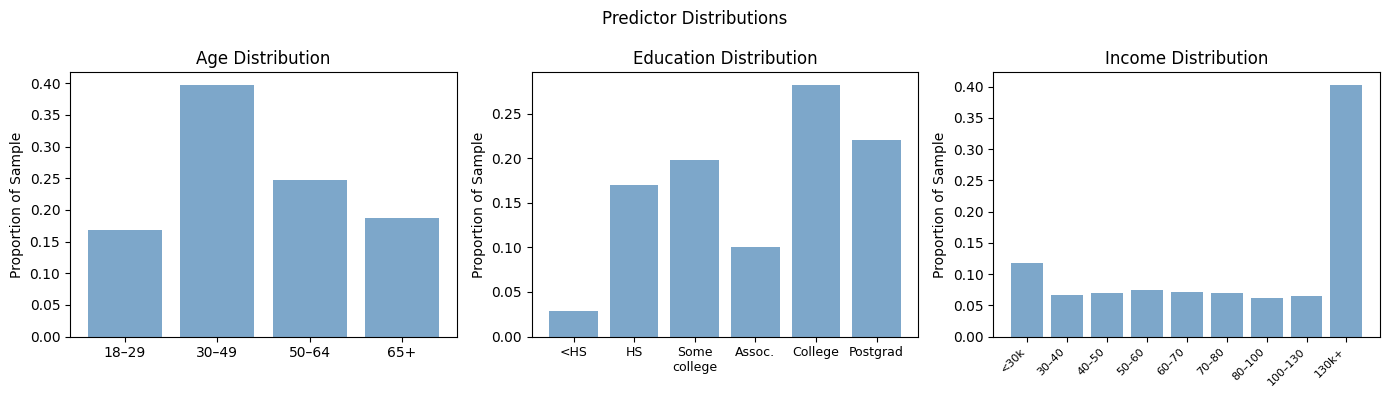

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Age density
age_counts = df_clean['age_cat'].value_counts(normalize=True).sort_index()
axes[0].bar(range(len(age_counts)), age_counts.values, color='steelblue', alpha=0.7)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(['18–29', '30–49', '50–64', '65+'])
axes[0].set_title('Age Distribution')
axes[0].set_ylabel('Proportion of Sample')

# Education bar
educ_counts = df_clean['educ_6cat'].value_counts(normalize=True).sort_index()
axes[1].bar(range(len(educ_counts)), educ_counts.values, color='steelblue', alpha=0.7)
axes[1].set_xticks(range(6))
axes[1].set_xticklabels(['<HS', 'HS', 'Some\ncollege', 'Assoc.',
                          'College', 'Postgrad'], fontsize=9)
axes[1].set_title('Education Distribution')
axes[1].set_ylabel('Proportion of Sample')

# Income bar
inc_counts = df_clean['inc_9cat'].value_counts(normalize=True).sort_index()
axes[2].bar(range(len(inc_counts)), inc_counts.values, color='steelblue', alpha=0.7)
axes[2].set_xticks(range(9))
axes[2].set_xticklabels(['<30k', '30–40', '40–50', '50–60', '60–70',
                          '70–80', '80–100', '100–130', '130k+'],
                          fontsize=8, rotation=45, ha='right')
axes[2].set_title('Income Distribution')
axes[2].set_ylabel('Proportion of Sample')

plt.suptitle('Predictor Distributions', fontsize=12)
plt.tight_layout()
plt.show()


# Step 2d: Weighted descriptive statistics
All descriptive claims use survey weights to represent the U.S. adult population aware of AI chatbots

In [ ]:
y       = df_clean['chatuse_binary']
weights = df_clean['weight']

# Overall weighted adoption rate
weighted_adoption   = np.average(y.values, weights=weights.values)
unweighted_adoption = y.mean()
print(f'Unweighted adoption rate: {unweighted_adoption:.3f}')
print(f'Weighted adoption rate:   {weighted_adoption:.3f}')
print()

# Weighted adoption rate by education
print('Weighted adoption rate by education:')
educ_label_map = {1: '<HS', 2: 'HS', 3: 'Some college',
                  4: 'Assoc.', 5: 'College', 6: 'Postgrad'}
for cat in sorted(df_clean['educ_6cat'].unique()):
    mask   = (df_clean['educ_6cat'] == cat).values
    wadopt = np.average(y.values[mask], weights=weights.values[mask])
    print(f'  {educ_label_map[int(cat)]:<15} {wadopt:.3f}  (n={mask.sum()})')
print()

# Weighted adoption rate by income
print('Weighted adoption rate by income:')
inc_label_map = {1: '<30k', 2: '30-40k', 3: '40-50k', 4: '50-60k',
                 5: '60-70k', 6: '70-80k', 7: '80-100k',
                 8: '100-130k', 9: '130k+'}
for cat in sorted(df_clean['inc_9cat'].unique()):
    mask   = (df_clean['inc_9cat'] == cat).values
    wadopt = np.average(y.values[mask], weights=weights.values[mask])
    print(f'  {inc_label_map[int(cat)]:<12} {wadopt:.3f}  (n={mask.sum()})')
print()

# Weighted adoption rate by age
print('Weighted adoption rate by age:')
age_label_map = {1: '18-29', 2: '30-49', 3: '50-64', 4: '65+'}
for cat in sorted(df_clean['age_cat'].unique()):
    mask   = (df_clean['age_cat'] == cat).values
    wadopt = np.average(y.values[mask], weights=weights.values[mask])
    print(f'  {age_label_map[int(cat)]:<10} {wadopt:.3f}  (n={mask.sum()})')

Unweighted adoption rate: 0.501
Weighted adoption rate:   0.470

Weighted adoption rate by education:
  <HS             0.279  (n=109)
  HS              0.352  (n=639)
  Some college    0.427  (n=743)
  Assoc.          0.495  (n=379)
  College         0.558  (n=1061)
  Postgrad        0.598  (n=827)

Weighted adoption rate by income:
  <30k         0.367  (n=443)
  30-40k       0.449  (n=252)
  40-50k       0.371  (n=264)
  50-60k       0.409  (n=282)
  60-70k       0.435  (n=266)
  70-80k       0.415  (n=264)
  80-100k      0.424  (n=231)
  100-130k     0.547  (n=242)
  130k+        0.572  (n=1514)

Weighted adoption rate by age:
  18-29      0.633  (n=633)
  30-49      0.518  (n=1493)
  50-64      0.378  (n=926)
  65+        0.238  (n=706)


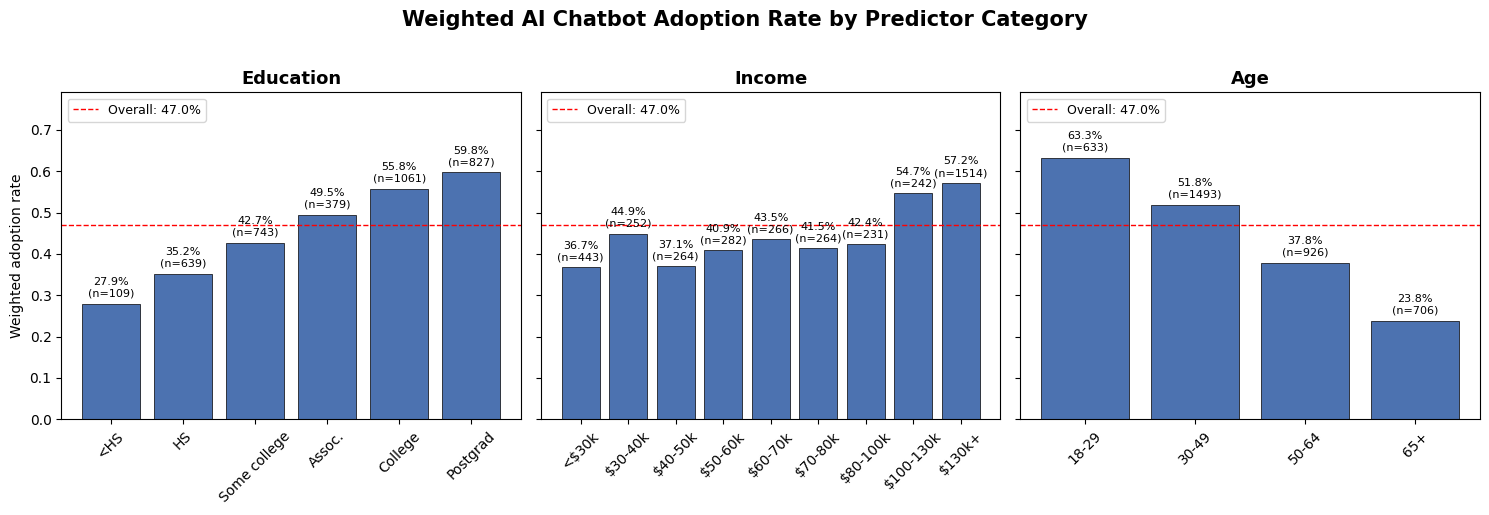

In [ ]:


# ── Compute all three sets of rates (reusing your existing logic) ──
educ_label_map = {1: '<HS', 2: 'HS', 3: 'Some college',
                  4: 'Assoc.', 5: 'College', 6: 'Postgrad'}
inc_label_map = {1: '<$30k', 2: '$30-40k', 3: '$40-50k', 4: '$50-60k',
                 5: '$60-70k', 6: '$70-80k', 7: '$80-100k',
                 8: '$100-130k', 9: '$130k+'}
age_label_map = {1: '18-29', 2: '30-49', 3: '50-64', 4: '65+'}

def weighted_rates(varname, label_map):
    cats, rates, ns = [], [], []
    for cat in sorted(df_clean[varname].unique()):
        mask = (df_clean[varname] == cat).values
        rates.append(np.average(y.values[mask], weights=weights.values[mask]))
        cats.append(label_map[int(cat)])
        ns.append(mask.sum())
    return cats, rates, ns

educ_cats, educ_rates, educ_ns = weighted_rates('educ_6cat', educ_label_map)
inc_cats,  inc_rates,  inc_ns  = weighted_rates('inc_9cat', inc_label_map)
age_cats,  age_rates,  age_ns  = weighted_rates('age_cat', age_label_map)

overall_rate = np.average(y.values, weights=weights.values)

# ── Plot: 3 panels side by side ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

panel_data = [
    (axes[0], educ_cats, educ_rates, educ_ns, 'Education'),
    (axes[1], inc_cats,  inc_rates,  inc_ns,  'Income'),
    (axes[2], age_cats,  age_rates,  age_ns,  'Age')
]

for ax, cats, rates, ns, title in panel_data:
    bars = ax.bar(cats, rates, color='#4C72B0', edgecolor='black', linewidth=0.5)
    ax.axhline(overall_rate, color='red', linestyle='--', linewidth=1,
               label=f'Overall: {overall_rate:.1%}')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(0, max(rates) * 1.25)
    ax.set_ylabel('Weighted adoption rate' if ax == axes[0] else '')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9, loc='upper left')

    # Annotate bars with percentage and n
    for bar, rate, n in zip(bars, rates, ns):
        ax.text(bar.get_x() + bar.get_width()/2, rate + max(rates)*0.02,
                f'{rate:.1%}\n(n={n})', ha='center', va='bottom', fontsize=8)

fig.suptitle('Weighted AI Chatbot Adoption Rate by Predictor Category',
              fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('weighted_adoption_rates.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 3: Build Feature Matrices

X_socio: education + income only (ordinal — rank order is meaningful)
X_full:  adds age (ordinal), gender and race (dummy-coded — nominal)
Reference categories: men, White non-Hispanic

In [ ]:
X_socio = df_clean[['educ_6cat', 'inc_9cat']]

gender_dummies = pd.get_dummies(df_clean['gender'], prefix='gender',
                                 drop_first=True).astype(float)
race_dummies   = pd.get_dummies(df_clean['race'],   prefix='race',
                                 drop_first=True).astype(float)

X_full = pd.concat(
    [df_clean[['educ_6cat', 'inc_9cat', 'age_cat']], gender_dummies, race_dummies],
    axis=1)

# Interaction term for Model 3
df_clean['inc_x_educ'] = df_clean['inc_9cat'] * df_clean['educ_6cat']
X_interact = pd.concat(
    [df_clean[['educ_6cat', 'inc_9cat', 'inc_x_educ', 'age_cat']],
     gender_dummies, race_dummies],
    axis=1)

print('X_socio columns:', list(X_socio.columns))
print('X_full columns: ', list(X_full.columns))
print('X_interact columns:', list(X_interact.columns))


X_socio columns: ['educ_6cat', 'inc_9cat']
X_full columns:  ['educ_6cat', 'inc_9cat', 'age_cat', 'gender_2.0', 'gender_3.0', 'race_2.0', 'race_3.0', 'race_4.0', 'race_5.0']
X_interact columns: ['educ_6cat', 'inc_9cat', 'inc_x_educ', 'age_cat', 'gender_2.0', 'gender_3.0', 'race_2.0', 'race_3.0', 'race_4.0', 'race_5.0']


## Step 4: Baseline Accuracy

The naive baseline is the accuracy of always predicting the majority class.
Since the sample is nearly 50/50, this baseline is only ~50% — any useful model should substantially exceed it.

In [ ]:
class_counts = y.value_counts(normalize=True)
baseline_acc = class_counts.max()

print('Class proportions:')
print(class_counts.round(3))
print('\nBaseline accuracy (always predict majority class):',
      round(baseline_acc, 3))

Class proportions:
chatuse_binary
1    0.501
0    0.499
Name: proportion, dtype: float64

Baseline accuracy (always predict majority class): 0.501


---
##  Models 1, 2, 3: Weighted logistic regression

Uses statsmodels GLM with binomial family and survey weights. Provides odds ratios, 95% CIs, and p-values for hypothesis testing

Logistic regression is a parametric model that gives us:
- **Odds ratios (OR)**: how much each predictor multiplies the odds of adoption
- **p-values and confidence intervals**: whether each effect is statistically significant
- **AIC/BIC**: for comparing model fit

We use `statsmodels` (rather than `sklearn`) here because it provides full inference output.


In [ ]:
X_socio_sm   = sm.add_constant(X_socio.astype(float))
X_full_sm    = sm.add_constant(X_full.astype(float))
X_interact_sm = sm.add_constant(X_interact.astype(float))

def get_or(model):
    """Extract odds ratios, CIs, and p-values from a fitted GLM."""
    return pd.DataFrame({
        'Odds Ratio': np.exp(model.params),
        'CI Lower':   np.exp(model.conf_int()[0]),
        'CI Upper':   np.exp(model.conf_int()[1]),
        'p-value':    model.pvalues
    }).round(3)

In [ ]:
# Model 1: SES only
glm_socio = sm.GLM(y, X_socio_sm,
                    family=sm.families.Binomial(),
                    var_weights=weights).fit()
print('Model 1 — Weighted ORs (SES only)')
print(get_or(glm_socio))
print(glm_socio.summary())

Model 1 — Weighted ORs (SES only)
           Odds Ratio  CI Lower  CI Upper  p-value
const           0.284     0.234     0.343      0.0
educ_6cat       1.244     1.186     1.305      0.0
inc_9cat        1.056     1.031     1.082      0.0
                 Generalized Linear Model Regression Results                  
Dep. Variable:         chatuse_binary   No. Observations:                 3758
Model:                            GLM   Df Residuals:                     3755
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2387.6
Date:                Thu, 11 Jun 2026   Deviance:                       4775.2
Time:                        05:29:10   Pearson chi2:                 3.57e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.04255
Covariance Type:            nonrobust              

In [ ]:
# Model 2: Full demographic
glm_full = sm.GLM(y, X_full_sm,
                   family=sm.families.Binomial(),
                   var_weights=weights).fit()
print('\nModel 2 — Weighted ORs (Full demographic)')
print('Reference categories: men, White non-Hispanic, age 18-29')
print(get_or(glm_full))
print(glm_full.summary())


Model 2 — Weighted ORs (Full demographic)
Reference categories: men, White non-Hispanic, age 18-29
            Odds Ratio  CI Lower  CI Upper  p-value
const            1.067     0.819     1.391    0.631
educ_6cat        1.296     1.231     1.365    0.000
inc_9cat         1.070     1.042     1.099    0.000
age_cat          0.528     0.489     0.571    0.000
gender_2.0       0.709     0.613     0.821    0.000
gender_3.0       1.183     0.552     2.535    0.666
race_2.0         1.082     0.855     1.369    0.512
race_3.0         1.832     1.396     2.403    0.000
race_4.0         0.959     0.699     1.316    0.796
race_5.0         0.778     0.542     1.116    0.173
                 Generalized Linear Model Regression Results                  
Dep. Variable:         chatuse_binary   No. Observations:                 3758
Model:                            GLM   Df Residuals:                     3748
Model Family:                Binomial   Df Model:                            9
Link Functio

In [ ]:
# Model 3: Income × education interaction — directly tests Hypothesis 2
glm_interact = sm.GLM(y, X_interact_sm,
                       family=sm.families.Binomial(),
                       var_weights=weights).fit()
print('\nModel 3 — Weighted ORs (Income × Education Interaction)')
print(get_or(glm_interact))
print(glm_interact.summary())


Model 3 — Weighted ORs (Income × Education Interaction)
            Odds Ratio  CI Lower  CI Upper  p-value
const            1.161     0.761     1.770    0.489
educ_6cat        1.265     1.134     1.411    0.000
inc_9cat         1.054     0.988     1.125    0.112
inc_x_educ       1.004     0.988     1.021    0.616
age_cat          0.528     0.489     0.571    0.000
gender_2.0       0.709     0.613     0.820    0.000
gender_3.0       1.171     0.547     2.510    0.684
race_2.0         1.079     0.853     1.366    0.526
race_3.0         1.829     1.394     2.400    0.000
race_4.0         0.959     0.699     1.317    0.798
race_5.0         0.776     0.541     1.113    0.168
                 Generalized Linear Model Regression Results                  
Dep. Variable:         chatuse_binary   No. Observations:                 3758
Model:                            GLM   Df Residuals:                     3747
Model Family:                Binomial   Df Model:                           10
Lin

In [ ]:
# Model fit comparison
print('\nModel fit comparison (lower AIC = better):')
print(f'  Model 1 (SES only) — AIC: {glm_socio.aic:.1f}')
print(f'  Model 2 (full)     — AIC: {glm_full.aic:.1f}')
print(f'  Model 3 (interact) — AIC: {glm_interact.aic:.1f}')
print('If Model 3 AIC < Model 2 AIC, the interaction improves fit.')


Model fit comparison (lower AIC = better):
  Model 1 (SES only) — AIC: 4781.2
  Model 2 (full)     — AIC: 4440.0
  Model 3 (interact) — AIC: 4441.8
If Model 3 AIC < Model 2 AIC, the interaction improves fit.


---
## Model 4 & 5: Random Forest

Used for predictive accuracy comparison only — not for predictor-specific inference

In [ ]:
# Encoding validation: ordinal vs dummy for RF
X_train, X_test, y_train, y_test = train_test_split(
    X_socio, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
acc_ordinal = accuracy_score(y_test, rf.predict(X_test))

X_dummy = pd.get_dummies(df_clean[['educ_6cat', 'inc_9cat']], drop_first=True)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dummy, y, test_size=0.2, random_state=42)
rf_d = RandomForestClassifier(n_estimators=100, random_state=42)
rf_d.fit(X_train_d, y_train_d)
acc_dummy = accuracy_score(y_test_d, rf_d.predict(X_test_d))

print(f'Ordinal encoding accuracy: {acc_ordinal:.4f}')
print(f'Dummy encoding accuracy:   {acc_dummy:.4f}')
print('Conclusion: equivalent — ordinal encoding used throughout.')


Ordinal encoding accuracy: 0.5984
Dummy encoding accuracy:   0.5984
Conclusion: equivalent — ordinal encoding used throughout.


---
## Step 5: Model Comparison — 5-Fold Cross-Validation

5-fold cross-validation gives a more stable estimate by averaging performance across 5 splits.

Includes accuracy, AUC, F1, precision, recall. Weights not applied here since model comparison is unaffected by weighting

- **Accuracy**: fraction of correct predictions
- **AUC**: area under the ROC curve — measures how well the model separates adopters from non-adopters (0.5 = chance, 1.0 = perfect)

In [ ]:
# F1, precision, and recall alongside accuracy

rf = RandomForestClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)

scoring = {
    'accuracy':  'accuracy',
    'auc':       'roc_auc',
    'f1':        make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall':    make_scorer(recall_score)
}

print('5-Fold Cross-Validation Results')
print('=' * 75)
print(f'{"Model":<35} {"Accuracy":>10} {"AUC":>10} {"F1":>8} '
      f'{"Precision":>10} {"Recall":>8}')
print('-' * 75)
print(f'{"Naive baseline":<35} {baseline_acc:.3f}')

for name, est, X in [
    ('Logistic — SES only',         lr, X_socio),
    ('Logistic — full demographic',  lr, X_full),
    ('Random Forest — SES only',     rf, X_socio),
    ('Random Forest — full demographic', rf, X_full)
]:
    scores = cross_validate(est, X, y, cv=5, scoring=scoring)
    acc  = scores['test_accuracy']
    auc  = scores['test_auc']
    f1   = scores['test_f1']
    prec = scores['test_precision']
    rec  = scores['test_recall']
    print(f'{name:<35} '
          f'{acc.mean():.3f}±{acc.std():.3f}  '
          f'{auc.mean():.3f}±{auc.std():.3f}  '
          f'{f1.mean():.3f}  '
          f'{prec.mean():.3f}  '
          f'{rec.mean():.3f}')

# Store accuracy scores for margin bar chart
cv_lr_socio_acc = cross_val_score(lr, X_socio, y, cv=5, scoring='accuracy')
cv_lr_full_acc  = cross_val_score(lr, X_full,  y, cv=5, scoring='accuracy')
cv_rf_socio_acc = cross_val_score(rf, X_socio, y, cv=5, scoring='accuracy')
cv_rf_full_acc  = cross_val_score(rf, X_full,  y, cv=5, scoring='accuracy')


5-Fold Cross-Validation Results
Model                                 Accuracy        AUC       F1  Precision   Recall
---------------------------------------------------------------------------
Naive baseline                      0.501
Logistic — SES only                 0.593±0.021  0.625±0.027  0.599  0.593  0.608
Logistic — full demographic         0.661±0.017  0.718±0.029  0.664  0.658  0.676
Random Forest — SES only            0.593±0.021  0.612±0.030  0.617  0.584  0.654
Random Forest — full demographic    0.622±0.011  0.654±0.014  0.625  0.621  0.631


In [ ]:
# F1, precision, and recall alongside accuracy

rf = RandomForestClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)

scoring = {
    'accuracy':  'accuracy',
    'auc':       'roc_auc',
    'f1':        make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall':    make_scorer(recall_score)
}

print('5-Fold Cross-Validation Results')
print('=' * 90)
print(f'{"Model":<35} {"Accuracy":>14} {"AUC":>14} {"F1":>14} '
      f'{"Precision":>14} {"Recall":>14}')
print('-' * 90)
print(f'{"Naive baseline":<35} {baseline_acc:.3f}')

results = []  # collect rows for the DataFrame

for name, est, X in [
    ('LR — SES only',                 lr, X_socio),
    ('LR — full demographic',         lr, X_full),
    ('RF — SES only',                 rf, X_socio),
    ('RF — full demographic',         rf, X_full)
]:
    scores = cross_validate(est, X, y, cv=5, scoring=scoring)
    acc  = scores['test_accuracy']
    auc  = scores['test_auc']
    f1   = scores['test_f1']
    prec = scores['test_precision']
    rec  = scores['test_recall']

    print(f'{name:<35} '
          f'{acc.mean():.3f}±{acc.std():.3f}  '
          f'{auc.mean():.3f}±{auc.std():.3f}  '
          f'{f1.mean():.3f}±{f1.std():.3f}  '
          f'{prec.mean():.3f}±{prec.std():.3f}  '
          f'{rec.mean():.3f}±{rec.std():.3f}')

    results.append({
        'Model':     name,
        'Accuracy':  f'{acc.mean():.3f} ± {acc.std():.3f}',
        'AUC':       f'{auc.mean():.3f} ± {auc.std():.3f}',
        'F1':        f'{f1.mean():.3f} ± {f1.std():.3f}',
        'Precision': f'{prec.mean():.3f} ± {prec.std():.3f}',
        'Recall':    f'{rec.mean():.3f} ± {rec.std():.3f}',
    })

# Add the naive baseline row at the top
baseline_row = {
    'Model':     'Naive baseline',
    'Accuracy':  f'{baseline_acc:.3f}',
    'AUC':       '—',
    'F1':        '—',
    'Precision': '—',
    'Recall':    '—',
}

table2_df = pd.DataFrame([baseline_row] + results)

print('\n')
print(table2_df.to_string(index=False))

# Export for Table 2 in your paper
table2_df.to_csv('table2_cv_results.csv', index=False)

# Store accuracy scores for margin bar chart
cv_lr_socio_acc = cross_val_score(lr, X_socio, y, cv=5, scoring='accuracy')
cv_lr_full_acc  = cross_val_score(lr, X_full,  y, cv=5, scoring='accuracy')
cv_rf_socio_acc = cross_val_score(rf, X_socio, y, cv=5, scoring='accuracy')
cv_rf_full_acc  = cross_val_score(rf, X_full,  y, cv=5, scoring='accuracy')

5-Fold Cross-Validation Results
Model                                     Accuracy            AUC             F1      Precision         Recall
------------------------------------------------------------------------------------------
Naive baseline                      0.501
LR — SES only                       0.593±0.021  0.625±0.027  0.599±0.025  0.593±0.026  0.608±0.054
LR — full demographic               0.661±0.017  0.718±0.029  0.664±0.033  0.658±0.017  0.676±0.075
RF — SES only                       0.593±0.021  0.612±0.030  0.617±0.023  0.584±0.020  0.654±0.039
RF — full demographic               0.622±0.011  0.654±0.014  0.625±0.023  0.621±0.013  0.631±0.052


                Model      Accuracy           AUC            F1     Precision        Recall
       Naive baseline         0.501             —             —             —             —
        LR — SES only 0.593 ± 0.021 0.625 ± 0.027 0.599 ± 0.025 0.593 ± 0.026 0.608 ± 0.054
LR — full demographic 0.661 ± 0.017 0.718 ± 0.

## Step 5b: New visualize model accuracy with margin bars

The margin bars answer is 62% actually better than 59% in a meaningful way, or do the confidence intervals overlap? If error bars on the RF-full and RF-SES bars don't overlap, the gain is real across folds.


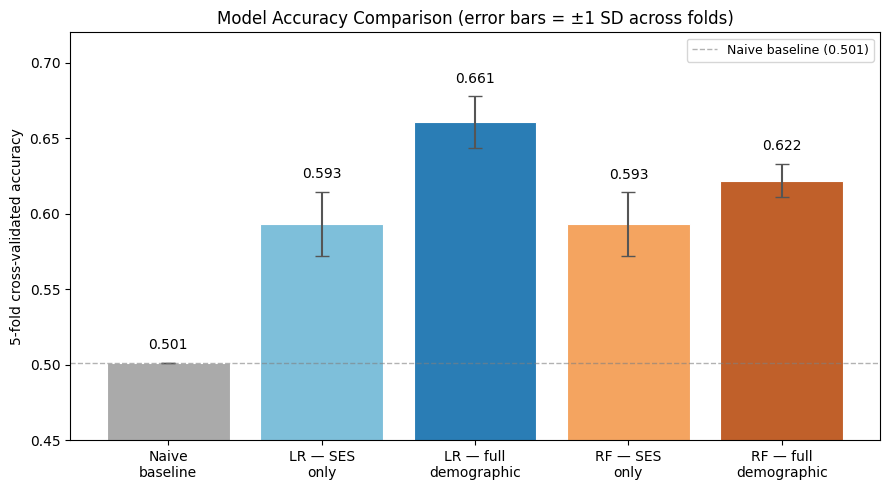

LR full model gain over baseline: 0.160 (31.9% relative)


In [ ]:
model_names = ['Naive\nbaseline', 'LR — SES\nonly',
               'LR — full\ndemographic', 'RF — SES\nonly',
               'RF — full\ndemographic']
means = [baseline_acc,
         cv_lr_socio_acc.mean(), cv_lr_full_acc.mean(),
         cv_rf_socio_acc.mean(), cv_rf_full_acc.mean()]
sds   = [0,
         cv_lr_socio_acc.std(), cv_lr_full_acc.std(),
         cv_rf_socio_acc.std(), cv_rf_full_acc.std()]
colors = ['#aaaaaa', '#7ebfda', '#2a7db5', '#f4a460', '#c0602a']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_names, means, yerr=sds, capsize=5,
              color=colors, edgecolor='white', linewidth=0.8,
              error_kw={'ecolor': '#555', 'linewidth': 1.5})
for bar, m, sd in zip(bars, means, sds):
    ax.text(bar.get_x() + bar.get_width() / 2, m + sd + 0.007,
            f'{m:.3f}', ha='center', va='bottom', fontsize=10)
ax.axhline(baseline_acc, color='gray', linestyle='--', linewidth=1,
           alpha=0.6, label=f'Naive baseline ({baseline_acc:.3f})')
ax.set_ylim(0.45, 0.72)
ax.set_ylabel('5-fold cross-validated accuracy')
ax.set_title('Model Accuracy Comparison (error bars = ±1 SD across folds)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'LR full model gain over baseline: '
      f'{cv_lr_full_acc.mean() - baseline_acc:.3f} '
      f'({(cv_lr_full_acc.mean()-baseline_acc)/baseline_acc*100:.1f}% relative)')


---
## Step 6: Visualization — Adoption Probability Heatmap

We fit the socioeconomic Random Forest on the full sample and use `predict_proba` to get
the predicted probability of adoption for every combination of education and income level.
This shows where the privilege gradient is steepest.

Fit RF on full sample for visualization only — not for evaluation

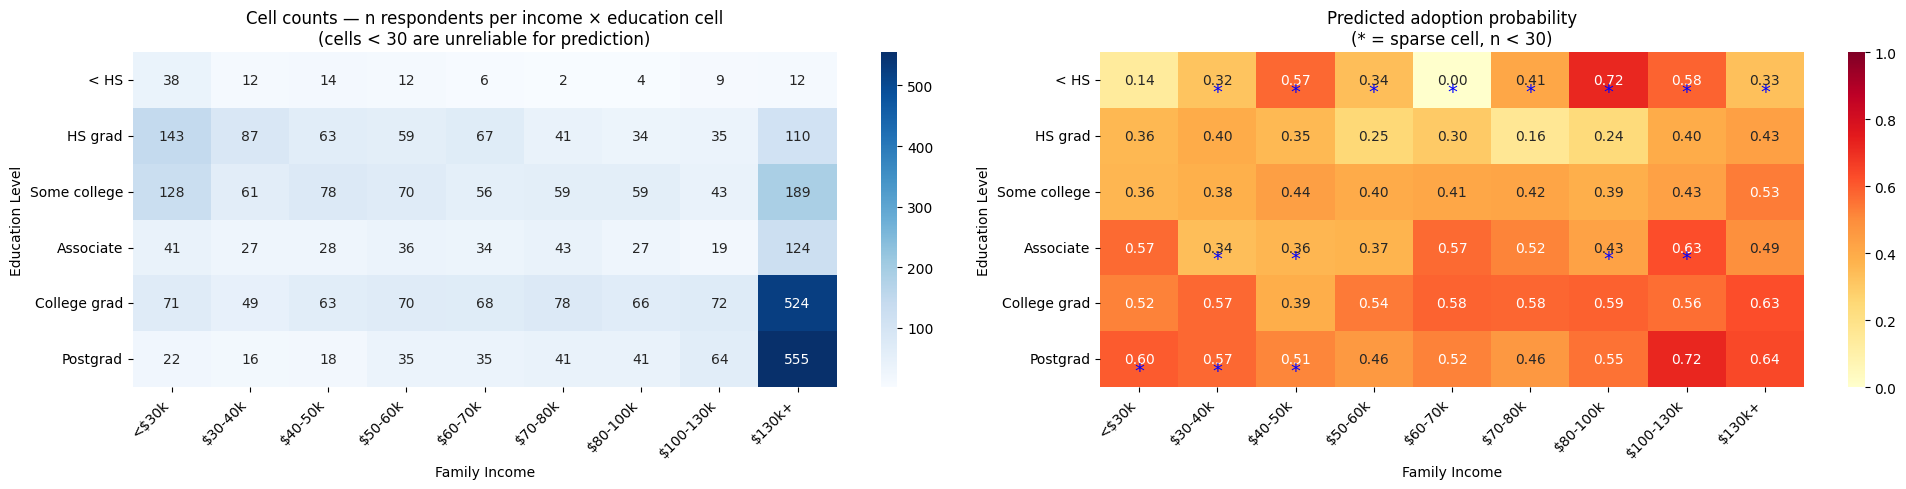

Saved: figure2_adoption_heatmap.png


In [ ]:
# Data sparsity heatmap alongside the adoption probability heatmap
# Cell count heatmap — shows where predictions are unreliable
educ_labels = ['< HS', 'HS grad', 'Some college',
               'Associate', 'College grad', 'Postgrad']
inc_labels  = ['<$30k', '$30-40k', '$40-50k', '$50-60k', '$60-70k',
               '$70-80k', '$80-100k', '$100-130k', '$130k+']

rf_viz = RandomForestClassifier(n_estimators=100, random_state=42)
rf_viz.fit(X_socio, y)

educ_vals = sorted(df_clean['educ_6cat'].unique())
inc_vals  = sorted(df_clean['inc_9cat'].unique())
grid = pd.DataFrame([{'educ_6cat': e, 'inc_9cat': i}
                     for e in educ_vals for i in inc_vals])
grid['prob_adopt'] = rf_viz.predict_proba(grid)[:, 1]
heatmap_data = grid.pivot(index='educ_6cat', columns='inc_9cat',
                           values='prob_adopt')

# Cell count heatmap (sparsity check)
count_data  = df_clean.groupby(['educ_6cat', 'inc_9cat']).size().reset_index(name='n')
count_pivot = count_data.pivot(index='educ_6cat', columns='inc_9cat', values='n')

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

sns.heatmap(count_pivot, annot=True, fmt='d', cmap='Blues',
            xticklabels=inc_labels, yticklabels=educ_labels, ax=axes[0])
axes[0].set_title('Cell counts — n respondents per income × education cell\n'
                  '(cells < 30 are unreliable for prediction)', fontsize=12)
axes[0].set_xlabel('Family Income')
axes[0].set_ylabel('Education Level')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1,
            xticklabels=inc_labels, yticklabels=educ_labels, ax=axes[1])

# Flag sparse cells with asterisk
for i, educ in enumerate(sorted(df_clean['educ_6cat'].unique())):
    for j, inc in enumerate(sorted(df_clean['inc_9cat'].unique())):
        try:
            n = count_pivot.loc[educ, inc]
        except KeyError:
            n = 0
        if n < 30:
            axes[1].text(j + 0.5, i + 0.8, '*',
                        ha='center', color='blue', fontsize=14)

axes[1].set_title('Predicted adoption probability\n(* = sparse cell, n < 30)',
                  fontsize=12)
axes[1].set_xlabel('Family Income')
axes[1].set_ylabel('Education Level')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('figure2_adoption_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figure2_adoption_heatmap.png')


---
## Step 7: Permutation importance (replaces MDI)

Replaces MDI entirely. One paragraph in Results, confirms LR ranking nonparametrically.
Answers: does the RF agree with logistic regression on which predictors matter?

Confirms logistic regression predictor ranking

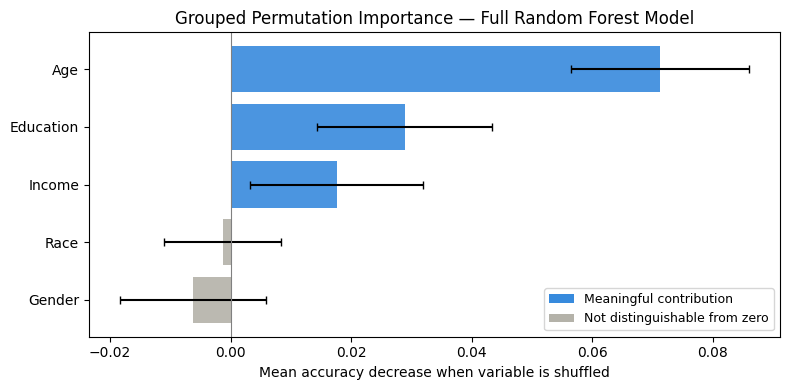

Grouped permutation importance values:
     feature  importance_mean  importance_std
2        Age           0.0712          0.0148
0  Education           0.0289          0.0145
1     Income           0.0176          0.0143
4       Race          -0.0013          0.0097
3     Gender          -0.0062          0.0121


In [ ]:


X_tr, X_te, y_tr, y_te = train_test_split(
    X_full, y, test_size=0.2, random_state=42)

rf_perm = RandomForestClassifier(n_estimators=100, random_state=42)
rf_perm.fit(X_tr, y_tr)

base_acc = accuracy_score(y_te, rf_perm.predict(X_te))

# Define variable groups — dummies for race/gender are shuffled together
variable_groups = {
    'Education': ['educ_6cat'],
    'Income':    ['inc_9cat'],
    'Age':       ['age_cat'],
    'Gender':    ['gender_2.0', 'gender_3.0'],
    'Race':      ['race_2.0', 'race_3.0', 'race_4.0', 'race_5.0']
}

n_repeats = 30
rng = np.random.RandomState(42)

results_mean = {}
results_std  = {}

X_te_df = pd.DataFrame(X_te, columns=X_full.columns).reset_index(drop=True)
y_te_arr = np.asarray(y_te)

for var_name, cols in variable_groups.items():
    drops = []
    for r in range(n_repeats):
        X_permuted = X_te_df.copy()
        shuffle_idx = rng.permutation(len(X_te_df))
        X_permuted[cols] = X_te_df[cols].values[shuffle_idx]
        permuted_acc = accuracy_score(y_te_arr, rf_perm.predict(X_permuted))
        drops.append(base_acc - permuted_acc)
    results_mean[var_name] = np.mean(drops)
    results_std[var_name]  = np.std(drops)

perm_imp = pd.DataFrame({
    'feature':         list(results_mean.keys()),
    'importance_mean': list(results_mean.values()),
    'importance_std':  list(results_std.values())
}).sort_values('importance_mean', ascending=True)

# Color: blue if error bars don't cross zero, gray if they do
colors = [
    '#378ADD' if (m - s > 0) else '#B4B2A9'
    for m, s in zip(perm_imp['importance_mean'], perm_imp['importance_std'])
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(perm_imp['feature'], perm_imp['importance_mean'],
        xerr=perm_imp['importance_std'],
        color=colors, capsize=3, alpha=0.9)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Mean accuracy decrease when variable is shuffled')
ax.set_title('Grouped Permutation Importance — Full Random Forest Model')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#378ADD', label='Meaningful contribution'),
    Patch(facecolor='#B4B2A9', label='Not distinguishable from zero')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print('Grouped permutation importance values:')
print(perm_imp.sort_values('importance_mean', ascending=False)
      [['feature', 'importance_mean', 'importance_std']].round(4))


---
## Step 8 Weighted Spearman correlations
Separate significance from effect size in the output.

Secondary outcome: frequency of AI use (useai) - useai is reverse-coded: 1 = almost constantly, 5 = less often


useai is a 5-point ordinal scale (1 = almost constantly, 5 = less often). We use Spearman rank correlation instead of Pearson because the spacing between ordinal categories is not necessarily equal.

A negative rho means higher SES is associated with more frequent use (lower score = more frequent).

In [ ]:
def weighted_spearman(x, y, w):
    """Approximate weighted Spearman by integer-expanding weights."""
    w_int = (w / w.min()).round().astype(int)
    x_exp = np.repeat(x.values, w_int)
    y_exp = np.repeat(y.values, w_int)
    return spearmanr(x_exp, y_exp)

rho_educ, p_educ = weighted_spearman(
    df_clean['educ_6cat'], df_clean['useai'], weights)
rho_inc, p_inc = weighted_spearman(
    df_clean['inc_9cat'], df_clean['useai'], weights)

print('Weighted Spearman correlations: SES predictors vs. AI use frequency')
print('-' * 60)
print(f'Education: rho = {rho_educ:.3f}, p = {p_educ:.4f}')
print(f'Income:    rho = {rho_inc:.3f},  p = {p_inc:.4f}')
print()
print('Interpretation:')
print(f'  p-values: both < .001 — direction is reliable at n = {len(df_clean):,}.')
print(f'  Effect sizes: |rho| .10–.29 = small by convention.')
print(f'  Education r² ~ {rho_educ**2*100:.1f}% of variance in use frequency.')
print(f'  Income    r² ~ {rho_inc**2*100:.1f}% of variance in use frequency.')
print(f'  useai reverse-coded: negative rho = higher SES → more frequent use.')

Weighted Spearman correlations: SES predictors vs. AI use frequency
------------------------------------------------------------
Education: rho = -0.152, p = 0.0000
Income:    rho = -0.130,  p = 0.0000

Interpretation:
  p-values: both < .001 — direction is reliable at n = 3,758.
  Effect sizes: |rho| .10–.29 = small by convention.
  Education r² ~ 2.3% of variance in use frequency.
  Income    r² ~ 1.7% of variance in use frequency.
  useai reverse-coded: negative rho = higher SES → more frequent use.


## Step 9: Secondary Analysis — Ordinal Logistic Regression on AI Use Frequency


##### `useai` is originally reverse-coded (1 = almost constantly, 5 = less often). We recode to useai_r (1 = less often, 5 = almost constantly) so that OR > 1 indicates more frequent use — consistent with how coefficients on education and income would naturally be read.
#
#####Analysis is restricted to the adopter subsample (chatuse_binary == 1, n = 1,883). Spearman correlations (Step 8) established bivariate SES–frequency associations; OLR extends this to a multivariate model mirroring the structure of the primary logistic regressions and allowing demographic adjustment.
#
#
#
####PROPORTIONAL-ODDS TEST (Brant test approximation)
-------------------------------------------------
##### The Brant test fits a binary logistic regression at each of the K-1 = 4 cumulative cut points and checks whether the coefficient for each predictor is stable across thresholds. A significant chi-square for a predictor indicates that predictor violates proportional odds. We use weighted GLMs consistent with the primary models.
#
##### If the assumption holds, we proceed with a single proportional-odds OLR via statsmodels OrderedModel. If it fails for one or more predictors, we note the violation and interpret results with caution (or use a partial proportional-odds model as a robustness check).

In [ ]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

# ── 0. Restrict to adopters and recode outcome ────────────────────────────────
df_adopters           = df_clean[df_clean['chatuse_binary'] == 1].copy().reset_index(drop=True)
df_adopters['useai_r'] = 6 - df_adopters['useai']   # recode: 5 = almost constantly
y_ord                 = df_adopters['useai_r'].astype(int)
weights_ord           = df_adopters['weight']

print(f'Adopter subsample: n = {len(df_adopters)}')
print('useai_r distribution (1=less often, 5=almost constantly):')
print(y_ord.value_counts().sort_index())

# ── 1. Build feature matrix ───────────────────────────────────────────────────
predictors   = ['educ_6cat', 'inc_9cat', 'age_cat']
gender_d_ord = pd.get_dummies(df_adopters['gender'], prefix='gender',
                               drop_first=True).astype(float)
race_d_ord   = pd.get_dummies(df_adopters['race'],   prefix='race',
                               drop_first=True).astype(float)
X_ord        = pd.concat([df_adopters[predictors], gender_d_ord, race_d_ord], axis=1)
all_preds    = list(X_ord.columns)

# ── 2. Brant test approximation ───────────────────────────────────────────────
thresholds   = [1, 2, 3, 4]
brant_coefs  = {p: [] for p in all_preds}

for k in thresholds:
    y_bin = (y_ord <= k).astype(int)
    X_sm  = sm.add_constant(X_ord.astype(float))
    glm_k = sm.GLM(y_bin, X_sm,
                   family=sm.families.Binomial(),
                   var_weights=weights_ord).fit()
    for p in all_preds:
        brant_coefs[p].append(glm_k.params[p])

print('\nBrant test approximation — coefficient stability across 4 cumulative cuts')
print(f'{"Predictor":<20} {"β@cut1":>8} {"β@cut2":>8} {"β@cut3":>8} '
      f'{"β@cut4":>8} {"SD":>8} {"Flag"}')
print('-' * 75)

brant_flags = {}
for p in all_preds:
    coefs = brant_coefs[p]
    sd    = np.std(coefs)
    flag  = '⚠ FAIL' if sd > 0.15 else 'pass'
    brant_flags[p] = (sd > 0.15)
    print(f'{p:<20} {coefs[0]:>8.3f} {coefs[1]:>8.3f} {coefs[2]:>8.3f} '
          f'{coefs[3]:>8.3f} {sd:>8.3f} {flag}')

n_failed = sum(brant_flags.values())
if n_failed == 0:
    print('\nProportional-odds assumption holds for all predictors. Proceeding with OLR.')
else:
    print(f'\n{n_failed} predictor(s) flagged. Interpret OLR results for flagged '
          f'predictors with caution — effect may not be uniform across thresholds.')

# ── 3. Ordinal logistic regression ───────────────────────────────────────────
# OrderedModel does not accept var_weights directly; integer-expand weights
# (same approach as weighted_spearman in Step 8).
w_int      = (weights_ord / weights_ord.min()).round().astype(int)
X_exp      = X_ord.loc[X_ord.index.repeat(w_int)].reset_index(drop=True)
y_exp      = y_ord.loc[y_ord.index.repeat(w_int)].reset_index(drop=True)

olr_model  = OrderedModel(y_exp, X_exp, distr='logit')
olr_result = olr_model.fit(method='bfgs', disp=False)

n_cutpoints = olr_result.model.k_extra
coef_params = olr_result.params.iloc[:-n_cutpoints]
coef_ci     = olr_result.conf_int().iloc[:-n_cutpoints]

olr_summary = pd.DataFrame({
    'Coef':     coef_params,
    'OR':       np.exp(coef_params),
    'CI Lower': np.exp(coef_ci.iloc[:, 0]),
    'CI Upper': np.exp(coef_ci.iloc[:, 1]),
    'p-value':  olr_result.pvalues.iloc[:-n_cutpoints]
}).round(3)

print('\nOrdinal Logistic Regression — AI use frequency (useai_r, adopters only)')
print('Reference categories: men, White non-Hispanic')
print('OR > 1 = higher predictor value → more frequent use\n')
print(olr_summary.to_string())
print(f'\nPseudo R² (McFadden): {1 - olr_result.llf / olr_result.llnull:.3f}')
print(olr_result.summary())

Adopter subsample: n = 1883
useai_r distribution (1=less often, 5=almost constantly):
useai_r
1    344
2    396
3    302
4    684
5    157
Name: count, dtype: int64

Brant test approximation — coefficient stability across 4 cumulative cuts
Predictor              β@cut1   β@cut2   β@cut3   β@cut4       SD Flag
---------------------------------------------------------------------------
educ_6cat              -0.089   -0.099   -0.086   -0.056    0.016 pass
inc_9cat               -0.050   -0.032   -0.033   -0.007    0.016 pass
age_cat                 0.151    0.033    0.049    0.000    0.056 pass
gender_2.0              0.002   -0.092   -0.020    0.143    0.085 pass
gender_3.0             -0.817    0.339    0.178   20.951    9.126 ⚠ FAIL
race_2.0                0.160   -0.049   -0.090   -0.374    0.190 ⚠ FAIL
race_3.0               -0.095    0.115    0.037   -0.502    0.238 ⚠ FAIL
race_4.0               -0.018   -0.261   -0.068   -0.784    0.303 ⚠ FAIL
race_5.0                0.733    0.19

In [ ]:
import pandas as pd

# ── Build a publication-ready OLR table ──
readable_labels = {
    'educ_6cat':  'Education',
    'inc_9cat':   'Income',
    'age_cat':    'Age',
    'gender_2.0': 'Gender (woman)',
    'gender_3.0': 'Gender (other)',
    'race_2.0':   'Race (Black)',
    'race_3.0':   'Race (Hispanic)',
    'race_4.0':   'Race (other)',
    'race_5.0':   'Race (Asian)'
}

def sig_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return ''

olr_table = pd.DataFrame({
    'Predictor': [readable_labels.get(idx, idx) for idx in olr_summary.index],
    'OR (95% CI)': [
        f"{row['OR']:.3f} ({row['CI Lower']:.3f}–{row['CI Upper']:.3f}){sig_stars(row['p-value'])}"
        for _, row in olr_summary.iterrows()
    ],
    'p-value': olr_summary['p-value'].apply(lambda p: '<.001' if p < 0.001 else f'{p:.3f}')
})

print(olr_table.to_string(index=False))

# Optional: render as a styled HTML table (for notebook display / export)
styled = (olr_table.style
          .set_caption('Table 3. Ordinal Logistic Regression — Frequency of AI Use Among Adopters')
          .hide(axis='index')
          .set_table_styles([
              {'selector': 'caption', 'props': [('font-weight', 'bold'),
                                                   ('font-size', '13px'),
                                                   ('text-align', 'left'),
                                                   ('padding-bottom', '8px')]},
              {'selector': 'th', 'props': [('background-color', '#f2f2f2'),
                                             ('text-align', 'left'),
                                             ('padding', '6px 12px')]},
              {'selector': 'td', 'props': [('padding', '6px 12px'),
                                             ('text-align', 'left')]}
          ]))
styled

      Predictor            OR (95% CI) p-value
      Education 1.092 (1.067–1.118)***   <.001
         Income 1.036 (1.024–1.049)***   <.001
            Age 0.938 (0.905–0.972)***   <.001
 Gender (woman)    1.014 (0.949–1.082)   0.687
 Gender (other)    0.897 (0.682–1.181)   0.440
   Race (Black)    1.053 (0.944–1.173)   0.353
Race (Hispanic)    1.036 (0.935–1.146)   0.502
   Race (other)  1.240 (1.073–1.432)**   0.004
   Race (Asian)  0.754 (0.627–0.906)**   0.003


Predictor,OR (95% CI),p-value
Education,1.092 (1.067–1.118)***,<.001
Income,1.036 (1.024–1.049)***,<.001
Age,0.938 (0.905–0.972)***,<.001
Gender (woman),1.014 (0.949–1.082),0.687
Gender (other),0.897 (0.682–1.181),0.440
Race (Black),1.053 (0.944–1.173),0.353
Race (Hispanic),1.036 (0.935–1.146),0.502
Race (other),1.240 (1.073–1.432)**,0.004
Race (Asian),0.754 (0.627–0.906)**,0.003


### Step 9 results: Ordinal logistic regression — AI use frequency

##### Among AI adopters (n = 1,883), ordinal logistic regression showed that higher education (OR = 1.091, p < .001) and higher income (OR = 1.036, p < .001) each independently predicted more frequent AI use after demographic adjustment. Older age predicted less frequent use (OR = 0.938, p < .001). Gender and most race categories were non-significant. The model explained very little variance overall (pseudo-R² = 0.005), indicating that SES and demographics account for minimal variation in use frequency among adopters. Socioeconomic stratification in AI engagement appears concentrated at the adoption decision itself; conditional on adoption, frequency of use is largely similar across SES groups.


In [ ]:
def format_or_ci(model, var, decimals=2):
    """Format odds ratio with 95% CI as 'OR (CI_low–CI_high)' with significance stars."""
    if var not in model.params.index:
        return '—'
    coef = model.params[var]
    or_val = np.exp(coef)
    ci = model.conf_int().loc[var]
    ci_low, ci_high = np.exp(ci[0]), np.exp(ci[1])
    pval = model.pvalues[var]

    stars = ''
    if pval < 0.001:
        stars = '***'
    elif pval < 0.01:
        stars = '**'
    elif pval < 0.05:
        stars = '*'

    return f'{or_val:.{decimals}f}{stars} ({ci_low:.{decimals}f}–{ci_high:.{decimals}f})'

# Variables to include — adjust names to match your model's coefficient labels
predictors = {
    'const':            'Intercept',
    'educ_6cat':        'Education',
    'inc_9cat':         'Income',
    'age_cat':          'Age',
    'gender_2.0':       'Gender (woman)',
    'gender_3.0':       'Gender (other)',
    'race_2.0':         'Race (Black)',
    'race_3.0':         'Race (Hispanic)',
    'race_4.0':         'Race (other)',
    'race_5.0':         'Race (Asian)',
    'inc_x_educ':       'Income × Education'
}

# Build the table
rows = []
for var_key, var_label in predictors.items():
    rows.append({
        'Predictor': var_label,
        'Model 1 (SES only)': format_or_ci(glm_socio, var_key),
        'Model 2 (+ demographics)': format_or_ci(glm_full, var_key),
        'Model 3 (+ interaction)': format_or_ci(glm_interact, var_key)
    })

# Add model fit statistics
rows.append({
    'Predictor': 'AIC',
    'Model 1 (SES only)': f'{glm_socio.aic:.1f}',
    'Model 2 (+ demographics)': f'{glm_full.aic:.1f}',
    'Model 3 (+ interaction)': f'{glm_interact.aic:.1f}'
})

def mcfadden_r2(model):
    return 1 - (model.llf / glm_socio.llnull)

rows.append({
    'Predictor': "McFadden's pseudo-R²",
    'Model 1 (SES only)': f'{mcfadden_r2(glm_socio):.3f}',
    'Model 2 (+ demographics)': f'{mcfadden_r2(glm_full):.3f}',
    'Model 3 (+ interaction)': f'{mcfadden_r2(glm_interact):.3f}'
})

rows.append({
    'Predictor': 'n',
    'Model 1 (SES only)': f'{int(glm_socio.nobs)}',
    'Model 2 (+ demographics)': f'{int(glm_full.nobs)}',
    'Model 3 (+ interaction)': f'{int(glm_interact.nobs)}'
})


comparison_table = pd.DataFrame(rows)

print("Logistic Regression Results: Odds Ratios and 95% Confidence Intervals Across Models")

print(comparison_table.to_string(index=False))
print()
print('Significance: *** p<.001, ** p<.01, * p<.05')

Logistic Regression Results: Odds Ratios and 95% Confidence Intervals Across Models
           Predictor  Model 1 (SES only) Model 2 (+ demographics) Model 3 (+ interaction)
           Intercept 0.28*** (0.23–0.34)         1.07 (0.82–1.39)        1.16 (0.76–1.77)
           Education 1.24*** (1.19–1.31)      1.30*** (1.23–1.36)     1.26*** (1.13–1.41)
              Income 1.06*** (1.03–1.08)      1.07*** (1.04–1.10)        1.05 (0.99–1.13)
                 Age                   —      0.53*** (0.49–0.57)     0.53*** (0.49–0.57)
      Gender (woman)                   —      0.71*** (0.61–0.82)     0.71*** (0.61–0.82)
      Gender (other)                   —         1.18 (0.55–2.53)        1.17 (0.55–2.51)
        Race (Black)                   —         1.08 (0.86–1.37)        1.08 (0.85–1.37)
     Race (Hispanic)                   —      1.83*** (1.40–2.40)     1.83*** (1.39–2.40)
        Race (other)                   —         0.96 (0.70–1.32)        0.96 (0.70–1.32)
        Race (As